In [ ]:
!pip install pandas scikit-learn
import pandas as pd
from sklearn.feature_extraction.text import TfidfVectorizer
from sklearn.model_selection import train_test_split
from sklearn.naive_bayes import BernoulliNB
from sklearn.linear_model import LogisticRegression
from sklearn.svm import LinearSVC
from sklearn.metrics import accuracy_score, classification_report

In [34]:
import kagglehub

path = kagglehub.dataset_download("jp797498e/twitter-entity-sentiment-analysis")

print("Path to dataset files:", path)

Using Colab cache for faster access to the 'twitter-entity-sentiment-analysis' dataset.
Path to dataset files: /kaggle/input/twitter-entity-sentiment-analysis


In [35]:
import os

# List the files in the downloaded dataset directory
print(os.listdir(path))

['twitter_validation.csv', 'twitter_training.csv']


Based on the file list, `tweet_emotions.csv` seems to be the main data file. Let's load it into a pandas DataFrame and display the first few rows.

In [36]:
csv_file_path = os.path.join(path, 'twitter_training.csv')
df = pd.read_csv(csv_file_path)
display(df.head())

,2401,Borderlands,Positive,"im getting on borderlands and i will murder you all ,"
0,2401,Borderlands,Positive,I am coming to the borders and I will kill you...
1,2401,Borderlands,Positive,im getting on borderlands and i will kill you ...
2,2401,Borderlands,Positive,im coming on borderlands and i will murder you...
3,2401,Borderlands,Positive,im getting on borderlands 2 and i will murder ...
4,2401,Borderlands,Positive,im getting into borderlands and i can murder y...


In [37]:
df.columns = ["id", "entity", "sentiment", "text"]

df.head()

,id,entity,sentiment,text
0,2401,Borderlands,Positive,I am coming to the borders and I will kill you...
1,2401,Borderlands,Positive,im getting on borderlands and i will kill you ...
2,2401,Borderlands,Positive,im coming on borderlands and i will murder you...
3,2401,Borderlands,Positive,im getting on borderlands 2 and i will murder ...
4,2401,Borderlands,Positive,im getting into borderlands and i can murder y...


In [38]:
df.isnull().sum()

,0
id,0
entity,0
sentiment,0
text,686


In [39]:
df.dropna(inplace=True)

In [40]:
df["sentiment"].value_counts()


,count
sentiment,
Negative,22358
Positive,20654
Neutral,18108
Irrelevant,12875


In [41]:
df = df[["text", "sentiment"]]

df.head()


,text,sentiment
0,I am coming to the borders and I will kill you...,Positive
1,im getting on borderlands and i will kill you ...,Positive
2,im coming on borderlands and i will murder you...,Positive
3,im getting on borderlands 2 and i will murder ...,Positive
4,im getting into borderlands and i can murder y...,Positive


In [ ]:
import re
import nltk
from nltk.corpus import stopwords

nltk.download('stopwords')

sw = set(stopwords.words('english'))

def clean(t):
    t = t.lower()
    t = re.sub(r"http\\S+", "", t)
    t = re.sub(r"[^a-zA-Z]", " ", t)
    t = t.split()
    t = [i for i in t if i not in sw]
    return " ".join(t)

df["text"] = df["text"].apply(clean)

In [43]:
x = df["text"]
y = df["sentiment"]

tf = TfidfVectorizer(max_features=5000)

x = tf.fit_transform(x)

In [44]:
xtr, xts, ytr, yts = train_test_split(
    x, y,
    test_size=0.2,
    random_state=42
)

In [ ]:
lr = LogisticRegression()

lr.fit(xtr, ytr)

p1 = lr.predict(xts)

print(accuracy_score(yts, p1))

In [46]:
print(classification_report(yts, p1))

              precision    recall  f1-score   support

  Irrelevant       0.70      0.54      0.61      2624
    Negative       0.70      0.80      0.75      4463
     Neutral       0.71      0.64      0.67      3589
    Positive       0.69      0.74      0.72      4123

    accuracy                           0.70     14799
   macro avg       0.70      0.68      0.69     14799
weighted avg       0.70      0.70      0.70     14799



In [47]:
sv = LinearSVC()

sv.fit(xtr, ytr)

p2 = sv.predict(xts)

print(accuracy_score(yts, p2))


0.7230893979322928


In [48]:
def pred(t):
    t = clean(t)
    t = tf.transform([t])

    ans = sv.predict(t)

    return ans[0]


In [49]:
pred("I love this game")

'Positive'

In [50]:
pred("This is terrible")

'Negative'

In [51]:
import pickle

pickle.dump(sv, open("model.pkl", "wb"))
pickle.dump(tf, open("vectorizer.pkl", "wb"))

In [52]:
df = df[df["sentiment"] != "Irrelevant"]

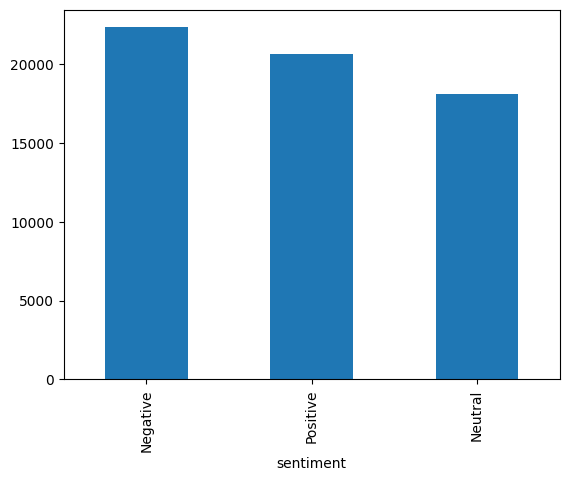

In [53]:
import matplotlib.pyplot as plt

df["sentiment"].value_counts().plot(kind="bar")

plt.show()

In [ ]:
!pip install streamlit pyngrok

In [55]:
!streamlit run app.py &>/content/logs.txt &

In [56]:
from pyngrok import ngrok

ngrok.set_auth_token('YOUR_NGROK_TOKEN')

public_url = ngrok.connect(8501)

print(public_url)

NgrokTunnel: "https://bladder-exodus-chatter.ngrok-free.dev" -> "http://localhost:8501"
